In [192]:
import Scrape_pokemon_functions as sp
import importlib
import pandas as pd
import re

In [193]:
import Scrape_pokemon_functions as sp
importlib.reload(sp)
import Scrape_pokemon_functions as sp

In [11]:
df = pd.read_csv('Data_Files/dropdown_df.csv')

In [111]:
gary = dropdown_df[dropdown_df['Deck'].str.contains('Gyarados ex')]

In [123]:
gary[gary['Deck'] == 'Gyarados ex Fan Rotom']

,Deck,Player,Date,Tournament,Placement,Player_Total,Score,Decklist_url,Tournament_url,Decklists,Expansion
15682,Gyarados ex Fan Rotom,Overmind,2025-02-26,⚡ #1 FASTER THAN THE LIGHT TOURNAMENT ⚡,163.0,260.0,1 - 2 - 0,/tournament/67be2bf978c0b323188202c6/player/ov...,/tournament/67be2bf978c0b323188202c6/details,"{""Amount"":{""0"":""2"",""1"":""2"",""2"":""2"",""3"":""1"",""4""...",Space-Time Smackdown


In [114]:
len(gary)

1167

In [126]:
# funny debugging

# regex = re.compile(r'(\w+ ?(?:ex)?) ?(\w+ ?(?:ex)?)?')
# #partners = []
# iss = []
# jss = []
# for j in range(len(gary['Deck'])):
#     matches = re.match(regex, gary['Deck'][j])
#     for i in (1,2):
#         if matches[i] != 'Gyarados ex':
#             print(matches[i], j)
#             iss.append(matches[i])
#             jss.append(j)
#             #if matches[i] is not None:
#                 #partners.append(matches[i].strip())
#             #else:
#                 #partners.append(matches[i])
# #partners = pd.Series(partners)
# iss = pd.Series(iss)
# jss = pd.Series(jss)

In [204]:
def get_partners(df, pokemon):
    regex = re.compile(r"([\w-']+ ?(?:ex)?) ?([\w-]+ ?(?:ex)?)?")
    partners = []
    filtered = df[df['Deck'].str.contains(pokemon)]
    for deck in filtered['Deck']:
        matches = re.match(regex, deck)
        for i in (1,2):
            if matches[i] != pokemon:
                if matches[i] is not None:
                    partners.append(matches[i].strip())
                else:
                    partners.append(f"Solo {pokemon}")
    partners = pd.Series(partners)
    return partners

In [200]:
data = get_partners(dropdown_df, "Gyarados ex").value_counts().head(5)

In [178]:
data = pd.DataFrame(data).reset_index().rename(columns={'index':'Partner','count':'Count'})

In [201]:
data = sp.get_partners(dropdown_df, 'Infernape ex')

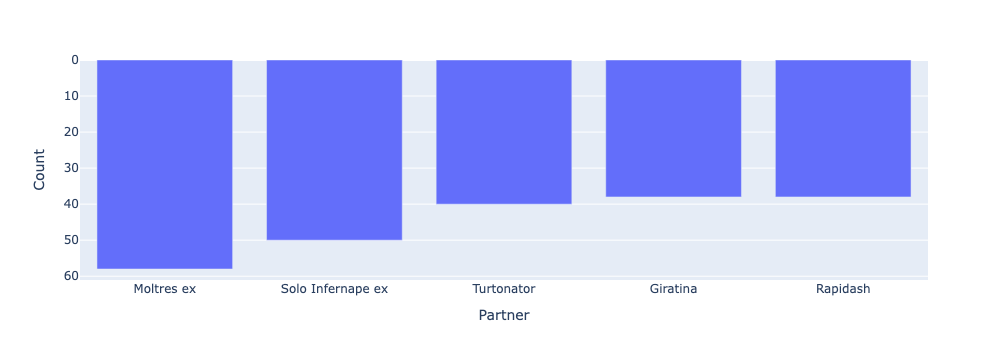

In [202]:
import plotly.express as px
fig = px.bar(data, x='Partner', y='Count',width=400)
fig['layout']['yaxis']['autorange'] = "reversed"
fig.show()